In [ ]:
import pandas as pd

In [ ]:
import os

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
print(os.listdir())

['.config', 'northstar_dataset_unzipped', 'northstar_dataset (2).zip', 'sample_data']


In [ ]:
!unzip -o '/content/northstar_dataset (2).zip' -d '/content/northstar_dataset_unzipped'
deliveries = pd.read_csv('/content/northstar_dataset_unzipped/northstar_dataset/deliveries.csv')
display(deliveries.head())

Archive:  /content/northstar_dataset (2).zip
  inflating: /content/northstar_dataset_unzipped/northstar_dataset/app_events.csv  
  inflating: /content/northstar_dataset_unzipped/northstar_dataset/complaints.csv  
  inflating: /content/northstar_dataset_unzipped/northstar_dataset/customers.csv  
  inflating: /content/northstar_dataset_unzipped/northstar_dataset/data_dictionary.csv  
  inflating: /content/northstar_dataset_unzipped/northstar_dataset/deliveries.csv  
  inflating: /content/northstar_dataset_unzipped/northstar_dataset/drivers.csv  
  inflating: /content/northstar_dataset_unzipped/northstar_dataset/hubs.csv  
  inflating: /content/northstar_dataset_unzipped/northstar_dataset/incidents.csv  
  inflating: /content/northstar_dataset_unzipped/northstar_dataset/orders.csv  
  inflating: /content/northstar_dataset_unzipped/northstar_dataset/README.txt  
  inflating: /content/northstar_dataset_unzipped/northstar_dataset/vehicles.csv  


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22


In [37]:
orders = pd.read_csv('/content/northstar_dataset_unzipped/northstar_dataset/orders.csv')
display(orders.head())

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0


In [38]:
import time

start = time.time()

high_priority = orders[orders['priority_level'] == 'High']

end = time.time()

print("Execution Time:", end - start)

Execution Time: 0.0008990764617919922


In [39]:
display(high_priority.head())

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
5,O00006,C0437,Retail,2024-08-05 04:55:00,1,CENTRAL,East,High,151.44,Web,1
14,O00015,C0300,Business,2025-11-09 03:04:00,6,SOUTH,East,High,145.58,Web,0
17,O00018,C0506,Passenger,2024-03-08 22:19:00,6,NORTH,Riverside,High,121.11,Phone,0
23,O00024,C0397,Passenger,2024-10-10 05:01:00,6,South,Riverside,High,132.20,App,1


In [ ]:
optimized_data = orders[['order_id', 'priority_level']]

high_priority_fast = optimized_data[
    optimized_data['priority_level'] == 'High'
]

display(high_priority_fast.head())

In [ ]:
status_count = deliveries['delivery_status'].value_counts()
print(status_count)

delivery_status
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64


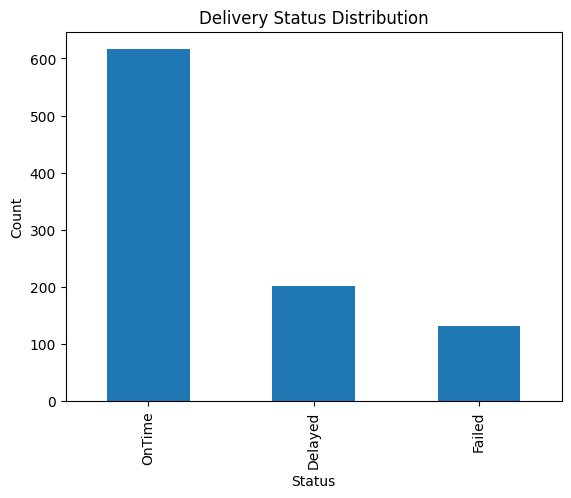

In [ ]:
status_count.plot(kind='bar')

plt.title('Delivery Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

In [ ]:
complaints = pd.read_csv('/content/northstar_dataset_unzipped/northstar_dataset/complaints.csv')

display(complaints.head())

,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
0,CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99
1,CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64
2,CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41
3,CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44
4,CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18


In [ ]:
complaint_count = complaints['complaint_type'].value_counts()

print(complaint_count)

complaint_type
Delay                101
MissedPickup          64
AppIssue              53
DriverBehaviour       51
SupportExperience     20
Billing               16
Damage                15
Name: count, dtype: int64


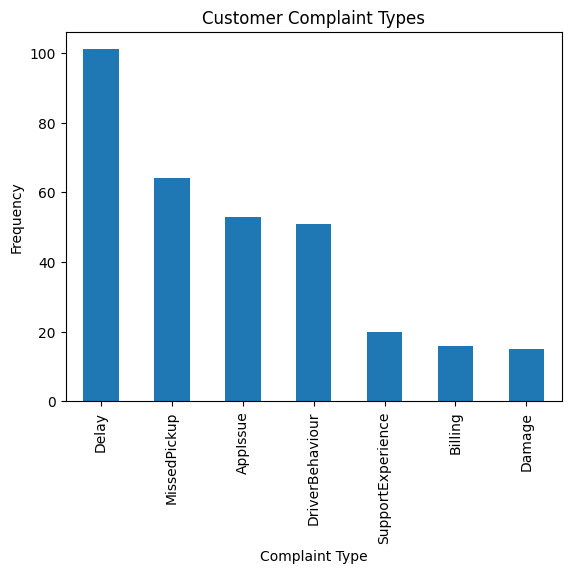

In [ ]:
complaint_count.plot(kind='bar')

plt.title('Customer Complaint Types')

plt.xlabel('Complaint Type')

plt.ylabel('Frequency')

plt.show()

In [ ]:
incidents = pd.read_csv('/content/northstar_dataset_unzipped/northstar_dataset/incidents.csv')

display(incidents.head())

,incident_id,delivery_id,incident_type,reported_at,severity,resolution_status,resolved_hours
0,I0001,DL00221,BatteryAlert,2024-03-11 23:46:00,Medium,Escalated,12.3
1,I0002,DL00578,BatteryAlert,2024-02-21 10:56:00,Low,Open,9.6
2,I0003,DL00175,TemperatureIssue,2025-04-17 23:22:00,Medium,Open,22.0
3,I0004,DL00417,ProofMissing,2025-02-09 00:16:00,Medium,Closed,9.8
4,I0005,DL00897,RouteDeviation,2025-01-04 02:49:00,Low,Open,13.0


In [ ]:
incident_count = incidents['incident_type'].value_counts()

print(incident_count)

incident_type
ProofMissing        46
CustomerNoShow      44
RouteDeviation      43
VehicleFault        37
BatteryAlert        36
AppSyncError        31
TemperatureIssue    29
SafetyNearMiss      14
Name: count, dtype: int64


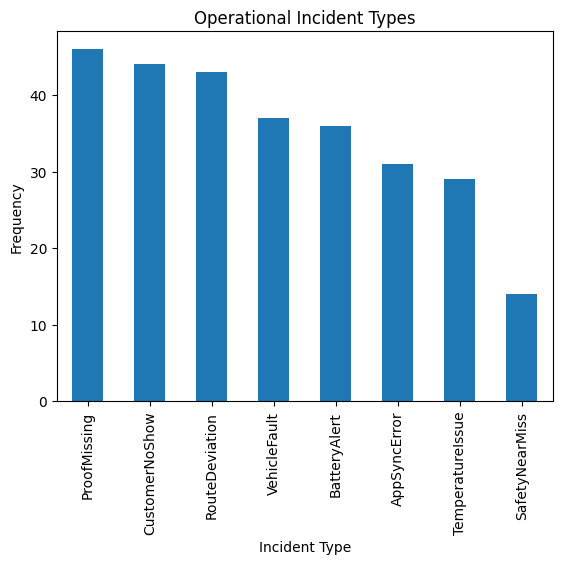

In [ ]:
incident_count.plot(kind='bar')

plt.title('Operational Incident Types')

plt.xlabel('Incident Type')

plt.ylabel('Frequency')

plt.show()

In [ ]:
drivers = pd.read_csv('/content/northstar_dataset_unzipped/northstar_dataset/drivers.csv')

display(drivers.head())

,driver_id,base_zone,employment_type,years_experience,training_score,driver_rating,shift_preference,active_flag
0,D001,AIRPORT,FullTime,8,67.8,3.54,Morning,1
1,D002,Central,FullTime,4,42.4,3.94,Evening,1
2,D003,AIRPORT,FullTime,11,96.5,5.00,Evening,1
3,D004,Airport,PartTime,13,88.9,4.75,Morning,1
4,D005,north,FullTime,3,69.7,4.14,Morning,1


In [ ]:
print(drivers.columns)

Index(['driver_id', 'base_zone', 'employment_type', 'years_experience',
       'training_score', 'driver_rating', 'shift_preference', 'active_flag'],
      dtype='object')


In [ ]:
driver_rating_count = drivers['driver_rating'].value_counts()

print(driver_rating_count)

driver_rating
4.48    8
4.07    5
3.99    5
4.40    5
5.00    5
       ..
4.42    1
4.50    1
3.89    1
4.64    1
3.81    1
Name: count, Length: 101, dtype: int64


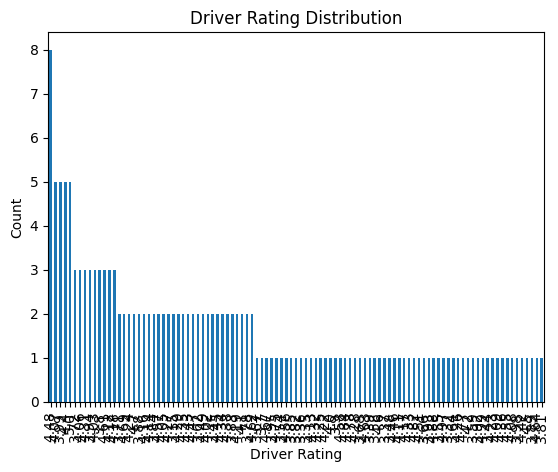

In [ ]:
driver_rating_count.plot(kind='bar')

plt.title('Driver Rating Distribution')

plt.xlabel('Driver Rating')

plt.ylabel('Count')

plt.show()

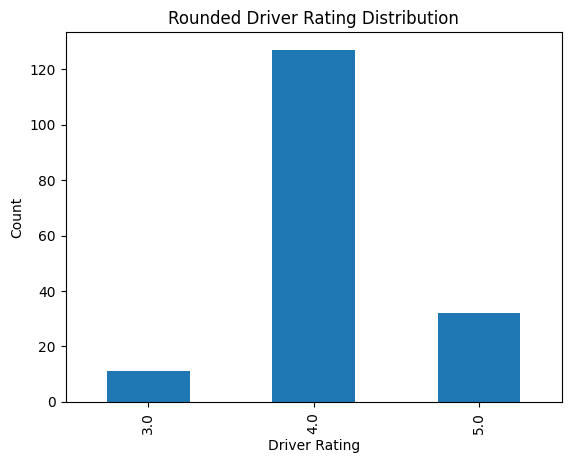

In [ ]:
drivers['driver_rating'].round().value_counts().sort_index().plot(kind='bar')

plt.title('Rounded Driver Rating Distribution')

plt.xlabel('Driver Rating')

plt.ylabel('Count')

plt.show()

In [ ]:
print(drivers['training_score'].describe())

count    163.000000
mean      74.914724
std       11.213827
min       40.600000
25%       68.550000
50%       75.200000
75%       82.750000
max       99.000000
Name: training_score, dtype: float64


In [ ]:
vehicles = pd.read_csv('/content/northstar_dataset_unzipped/northstar_dataset/vehicles.csv')

display(vehicles.head())

,vehicle_id,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version
0,V001,EV,North,2024-12-28 23:48:00,71.8,56928,Active,v2.2
1,V002,EV,AIRPORT,2024-04-21 16:14:00,67.9,159368,InRepair,v2.2
2,V003,CargoVan,north,2025-11-24 23:59:00,91.7,219359,Active,v2.1
3,V004,Hybrid,RiverSide,2024-06-07 13:21:00,NaN,36310,Active,v2.2
4,V005,CargoVan,West,2025-11-15 11:08:00,58.6,146638,Active,v2.2


In [ ]:
print(vehicles.columns)

Index(['vehicle_id', 'vehicle_type', 'assigned_zone', 'commission_date',
       'battery_health_pct', 'odometer_km', 'maintenance_status',
       'telematics_version'],
      dtype='object')


In [ ]:
maintenance_count = vehicles['maintenance_status'].value_counts()

print(maintenance_count)

maintenance_status
Active       67
InRepair     36
Scheduled    17
Name: count, dtype: int64


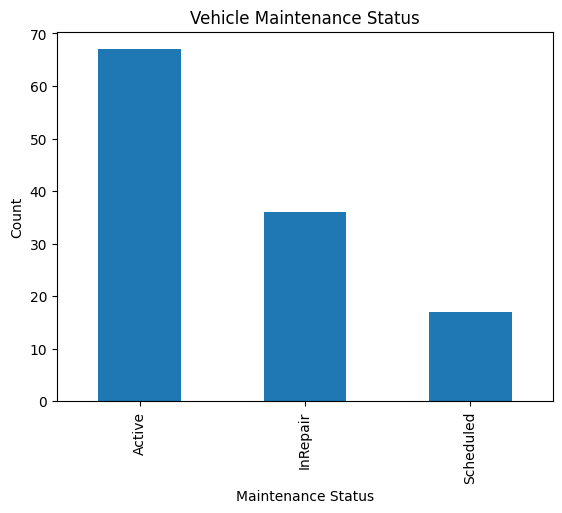

In [ ]:
maintenance_count.plot(kind='bar')

plt.title('Vehicle Maintenance Status')

plt.xlabel('Maintenance Status')

plt.ylabel('Count')

plt.show()

In [ ]:
print(vehicles['battery_health_pct'].describe())

count    116.000000
mean      76.785345
std       12.698985
min       42.000000
25%       68.200000
50%       78.050000
75%       85.775000
max      100.000000
Name: battery_health_pct, dtype: float64
